# Partie I — MLP et ingénierie PyTorch
## Classification supervisée sur données tabulaires : Breast Cancer Wisconsin

**Module :** Deep Learning  
**Année universitaire :** 2025–2026  
**Dataset :** Breast Cancer Wisconsin (Diagnostic)  
**Tâche :** Classification binaire — tumeur bénigne vs. maligne

---
## 1. Concepts fondamentaux de PyTorch

### 1.1 `nn.Module`

`nn.Module` est la classe de base de tout modèle PyTorch. Elle offre :
- Un registre automatique des **paramètres apprenables** (poids et biais)
- Une méthode `forward()` à redéfinir pour décrire le passage avant
- Des utilitaires intégrés : `.parameters()`, `.named_parameters()`, `.state_dict()`, `.to(device)`, `.train()`, `.eval()`

Toute architecture (MLP, CNN, RNN…) hérite de `nn.Module`.

### 1.2 Paramètres et gradient

Un **paramètre** est un tenseur dont `requires_grad=True`. PyTorch maintient un graphe de calcul dynamique (*autograd*). Lors de l'appel `.backward()`, les gradients sont calculés par la règle de dérivation en chaîne et stockés dans `param.grad`.

L'optimiseur lit ces gradients pour mettre à jour les poids :
$$\theta \leftarrow \theta - \eta \cdot \nabla_{\theta} \mathcal{L}$$

### 1.3 `state_dict`

`model.state_dict()` retourne un dictionnaire ordonné `{nom_couche: tenseur}` de tous les paramètres et buffers du modèle. C'est la représentation canonique pour sauvegarder et recharger un modèle.

### 1.4 Device (CPU / GPU)

PyTorch permet d'exécuter les calculs sur CPU ou GPU (CUDA). Il est impératif que **le modèle et les données soient sur le même device**. On utilise `.to(device)` pour déplacer tenseurs et modules.

### 1.5 Propagation avant et rétropropagation

- **Forward pass** : calcul de la sortie $\hat{y} = f(x; \theta)$ couche par couche.
- **Loss** : mesure de l'écart entre $\hat{y}$ et $y$ (ex. Binary Cross-Entropy).
- **Backward pass** : calcul de $\nabla_{\theta} \mathcal{L}$ via la rétropropagation du gradient.
- **Update** : l'optimiseur modifie $\theta$ dans le sens de la descente de gradient.

---
## 2. Imports et configuration

In [21]:
import sys
print('Python utilisé par ce kernel :', sys.executable)
%pip install --quiet numpy pandas matplotlib seaborn scikit-learn torch torchvision

Python utilisé par ce kernel : c:\Users\lenovo\Desktop\Projet Deep Learning\.venv\Scripts\python.exe
Note: you may need to restart the kernel to use updated packages.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')
if device.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  Mémoire GPU : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Device utilisé : cpu


---
## 3. Préparation des données

### 3.1 Chargement du dataset

In [23]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = maligne, 1 = bénigne

print(f'Dimensions : {X.shape}')
print(f'Classes    : {dict(zip(["maligne", "bénigne"], np.bincount(y)))}')
print(f'\nAperçu des features :')
X.describe().round(2)

Dimensions : (569, 30)
Classes    : {'maligne': np.int64(212), 'bénigne': np.int64(357)}

Aperçu des features :


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


### 3.2 Vérification de la qualité des données

Valeurs manquantes par colonne :
0 → aucune valeur manquante


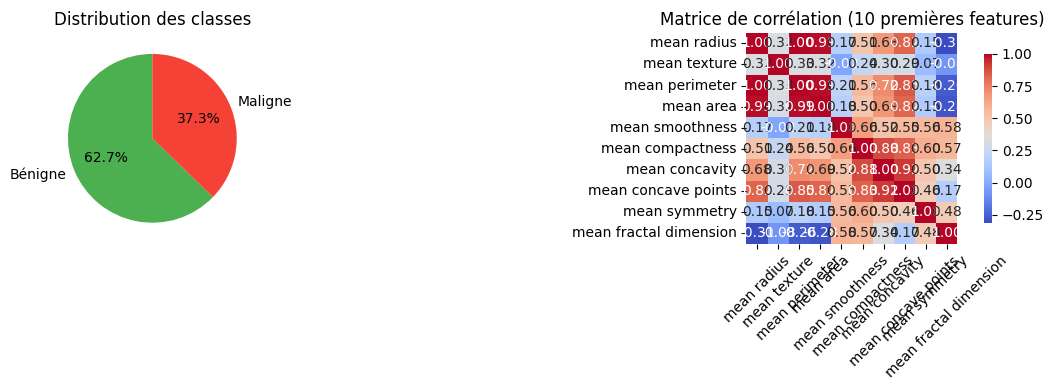

In [24]:
print('Valeurs manquantes par colonne :')
print(X.isnull().sum().sum(), '→ aucune valeur manquante')

# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Diagramme camembert
counts = y.value_counts()
axes[0].pie(counts, labels=['Bénigne', 'Maligne'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Distribution des classes')

# Corrélation (heatmap sur les 10 premières features)
corr = X.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Matrice de corrélation (10 premières features)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('correlation_breast_cancer.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Division train / validation / test et normalisation

La normalisation (StandardScaler) est **calculée uniquement sur le train** pour éviter toute fuite d'information (*data leakage*) vers la validation et le test.

In [25]:
# 70% train — 15% val — 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X.values, y.values, test_size=0.30, random_state=SEED, stratify=y.values)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# Normalisation Z-score
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} exemples')
print(f'Val   : {X_val.shape[0]} exemples')
print(f'Test  : {X_test.shape[0]} exemples')

# Conversion en tenseurs PyTorch
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1))

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t,   y_val_t   = to_tensor(X_val,   y_val)
X_test_t,  y_test_t  = to_tensor(X_test,  y_test)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE)

Train : 398 exemples
Val   : 85 exemples
Test  : 86 exemples


---
## 4. Implémentation du MLP

### 4.1 Version `nn.Sequential`

`nn.Sequential` empile des couches dans un conteneur ordonné. C'est la syntaxe la plus concise pour des architectures *feed-forward* sans branchement.

In [26]:
INPUT_DIM  = X_train.shape[1]  # 30 features
HIDDEN1    = 64
HIDDEN2    = 32
OUTPUT_DIM = 1                  # sortie scalaire → sigmoid → proba

mlp_sequential = nn.Sequential(
    nn.Linear(INPUT_DIM, HIDDEN1),
    nn.BatchNorm1d(HIDDEN1),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(HIDDEN1, HIDDEN2),
    nn.BatchNorm1d(HIDDEN2),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(HIDDEN2, OUTPUT_DIM),
    nn.Sigmoid()
)

print('Architecture MLP (Sequential) :')
print(mlp_sequential)
total_params = sum(p.numel() for p in mlp_sequential.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {total_params:,}')

Architecture MLP (Sequential) :
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=32, out_features=1, bias=True)
  (9): Sigmoid()
)

Paramètres entraînables : 4,289


### 4.2 Version classe personnalisée (`nn.Module`)

La classe personnalisée offre plus de flexibilité : branchements conditionnels, couches partagées, accès aux activations intermédiaires.

In [27]:
class MLP(nn.Module):
    """Perceptron multicouche pour classification binaire."""

    def __init__(self, input_dim: int, hidden_dims: list, dropout_rates: list):
        super().__init__()
        assert len(dropout_rates) == len(hidden_dims)

        layers = []
        prev_dim = input_dim
        for h_dim, drop in zip(hidden_dims, dropout_rates):
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=drop))
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.network(x))

    def predict(self, x: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            proba = self.forward(x)
        return (proba >= threshold).long().squeeze()


mlp_custom = MLP(
    input_dim=INPUT_DIM,
    hidden_dims=[HIDDEN1, HIDDEN2],
    dropout_rates=[0.3, 0.2]
)

print('Architecture MLP (classe personnalisée) :')
print(mlp_custom)
total_params = sum(p.numel() for p in mlp_custom.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {total_params:,}')

Architecture MLP (classe personnalisée) :
MLP(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Paramètres entraînables : 4,289


---
## 5. Inspection des paramètres

### 5.1 `named_parameters()`

In [28]:
print(f'{"Nom de la couche":<45} {"Forme":<20} {"Nb params":>10}')
print('-' * 80)
total = 0
for name, param in mlp_custom.named_parameters():
    n = param.numel()
    total += n
    print(f'{name:<45} {str(tuple(param.shape)):<20} {n:>10,}')
print('-' * 80)
print(f'{"TOTAL":<45} {"":20} {total:>10,}')

Nom de la couche                              Forme                 Nb params
--------------------------------------------------------------------------------
network.0.weight                              (64, 30)                  1,920
network.0.bias                                (64,)                        64
network.1.weight                              (64,)                        64
network.1.bias                                (64,)                        64
network.4.weight                              (32, 64)                  2,048
network.4.bias                                (32,)                        32
network.5.weight                              (32,)                        32
network.5.bias                                (32,)                        32
network.8.weight                              (1, 32)                      32
network.8.bias                                (1,)                          1
-------------------------------------------------------------

### 5.2 `state_dict()`

In [29]:
sd = mlp_custom.state_dict()
print('Clés du state_dict :')
for key in sd:
    print(f'  {key:<50} → shape {tuple(sd[key].shape)}')

# Extrait des valeurs initiales de la première couche
print('\nExtrait des poids initiaux (réseau.0.weight) :')
print(sd['network.0.weight'][:3, :5].numpy().round(4))

Clés du state_dict :
  network.0.weight                                   → shape (64, 30)
  network.0.bias                                     → shape (64,)
  network.1.weight                                   → shape (64,)
  network.1.bias                                     → shape (64,)
  network.1.running_mean                             → shape (64,)
  network.1.running_var                              → shape (64,)
  network.1.num_batches_tracked                      → shape ()
  network.4.weight                                   → shape (32, 64)
  network.4.bias                                     → shape (32,)
  network.5.weight                                   → shape (32,)
  network.5.bias                                     → shape (32,)
  network.5.running_mean                             → shape (32,)
  network.5.running_var                              → shape (32,)
  network.5.num_batches_tracked                      → shape ()
  network.8.weight                       

---
## 6. Stratégies d'initialisation

L'initialisation des poids conditionne fortement la convergence. Trois stratégies sont comparées :

| Stratégie | Distribution | Avantage |
|-----------|-------------|----------|
| Gaussienne | $\mathcal{N}(0, 0.01)$ | Simple, contrôle facile de la variance |
| Constante | 0 | Symétrie — **à éviter** en pratique |
| Xavier (Glorot) | $\mathcal{U}\left(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$ | Maintient la variance des activations |

In [30]:
def init_gaussian(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, val=0.0)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# Créer 3 modèles avec des initialisations différentes
configs = [
    ('Gaussienne', init_gaussian),
    ('Constante',  init_constant),
    ('Xavier',     init_xavier),
]

models_init = {}
for name, init_fn in configs:
    m = MLP(INPUT_DIM, [HIDDEN1, HIDDEN2], [0.3, 0.2])
    m.apply(init_fn)
    models_init[name] = m
    w = m.state_dict()['network.0.weight']
    print(f'Init {name:<12} → mean={w.mean().item():.5f}, std={w.std().item():.5f}, '
          f'min={w.min().item():.5f}, max={w.max().item():.5f}')

Init Gaussienne   → mean=-0.00013, std=0.01009, min=-0.03092, max=0.03133
Init Constante    → mean=0.00000, std=0.00000, min=0.00000, max=0.00000
Init Xavier       → mean=0.00433, std=0.14547, min=-0.25260, max=0.25245


---
## 7. Boucle d'entraînement — comparaison des initialisations

In [31]:
def train_epoch(model, loader, optimizer, criterion, dev):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += ((preds >= 0.5).float() == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, dev):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += ((preds >= 0.5).float() == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


EPOCHS    = 100
LR        = 1e-3
criterion = nn.BCELoss()

history = {}

for init_name, model in models_init.items():
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    h = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = eval_epoch(model,  val_loader,   criterion, device)
        scheduler.step()
        h['train_loss'].append(tr_loss)
        h['val_loss'].append(vl_loss)
        h['train_acc'].append(tr_acc)
        h['val_acc'].append(vl_acc)

    history[init_name] = h
    best_val = max(h['val_acc'])
    print(f'[{init_name:<12}] Best val acc : {best_val:.4f}')

[Gaussienne  ] Best val acc : 1.0000
[Constante   ] Best val acc : 0.6235
[Xavier      ] Best val acc : 1.0000


### 7.1 Visualisation des courbes d'apprentissage

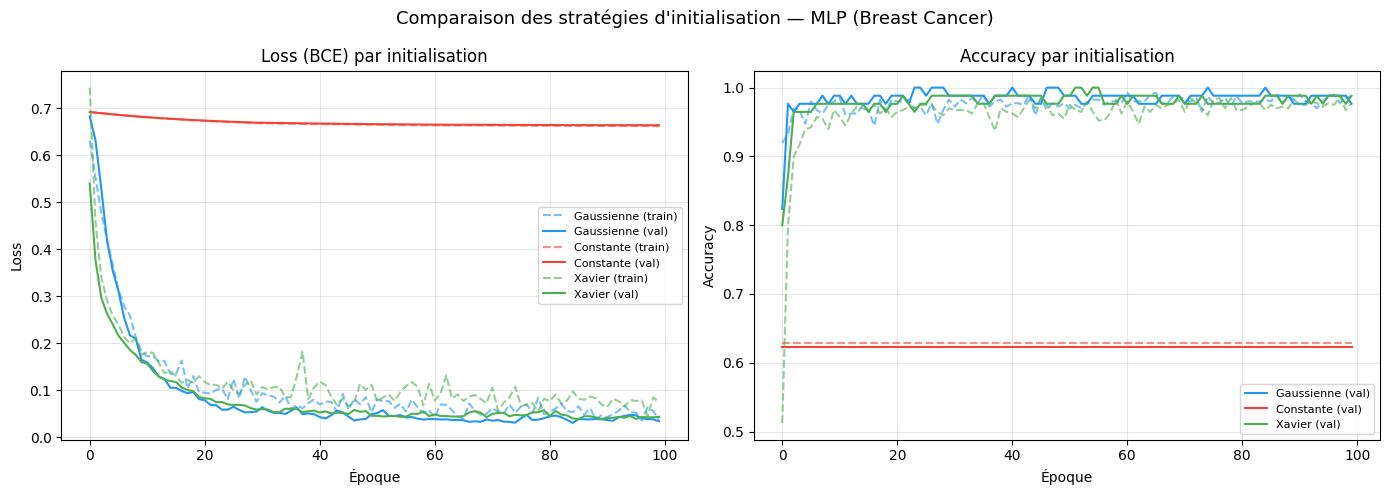

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Gaussienne': '#2196F3', 'Constante': '#F44336', 'Xavier': '#4CAF50'}

for init_name, h in history.items():
    c = colors[init_name]
    axes[0].plot(h['train_loss'], color=c, linestyle='--', alpha=0.6, label=f'{init_name} (train)')
    axes[0].plot(h['val_loss'],   color=c, linestyle='-',  label=f'{init_name} (val)')
    axes[1].plot(h['train_acc'],  color=c, linestyle='--', alpha=0.6)
    axes[1].plot(h['val_acc'],    color=c, linestyle='-',  label=f'{init_name} (val)')

axes[0].set_title('Loss (BCE) par initialisation')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title('Accuracy par initialisation')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Comparaison des stratégies d\'initialisation — MLP (Breast Cancer)', fontsize=13)
plt.tight_layout()
plt.savefig('init_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Entraînement du meilleur modèle (Xavier) avec Early Stopping

In [33]:
EPOCHS_FULL  = 200
PATIENCE     = 20
SAVE_PATH    = 'best_mlp.pt'

best_model = MLP(INPUT_DIM, [HIDDEN1, HIDDEN2], [0.3, 0.2])
best_model.apply(init_xavier)
best_model = best_model.to(device)

optimizer  = optim.Adam(best_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                    factor=0.5, patience=10)

best_val_loss  = float('inf')
patience_count = 0
full_history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS_FULL + 1):
    tr_loss, tr_acc = train_epoch(best_model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc = eval_epoch(best_model,  val_loader,   criterion, device)
    scheduler.step(vl_loss)

    full_history['train_loss'].append(tr_loss)
    full_history['val_loss'].append(vl_loss)
    full_history['train_acc'].append(tr_acc)
    full_history['val_acc'].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        patience_count = 0
        torch.save(best_model.state_dict(), SAVE_PATH)
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping à l\'époque {epoch}')
            break

    if epoch % 20 == 0:
        print(f'Époque {epoch:3d} | Train loss {tr_loss:.4f} acc {tr_acc:.4f} '
              f'| Val loss {vl_loss:.4f} acc {vl_acc:.4f}')

print(f'\nMeilleur modèle sauvegardé → {SAVE_PATH}')

Époque  20 | Train loss 0.0938 acc 0.9673 | Val loss 0.0799 acc 0.9765
Époque  40 | Train loss 0.0587 acc 0.9849 | Val loss 0.0415 acc 0.9882
Époque  60 | Train loss 0.0500 acc 0.9874 | Val loss 0.0363 acc 0.9882
Époque  80 | Train loss 0.0383 acc 0.9874 | Val loss 0.0313 acc 0.9882
Early stopping à l'époque 88

Meilleur modèle sauvegardé → best_mlp.pt


---
## 9. Sauvegarde et rechargement du meilleur modèle

In [34]:
# Rechargement dans un nouveau modèle
loaded_model = MLP(INPUT_DIM, [HIDDEN1, HIDDEN2], [0.3, 0.2])
loaded_model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
loaded_model = loaded_model.to(device)
loaded_model.eval()

# best_model a continué de s'entraîner après la sauvegarde du meilleur checkpoint
# → on le resynchronise avec le checkpoint sauvegardé avant de comparer
best_model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))

# Vérification : tous les tenseurs doivent être identiques
all_match = True
for key in best_model.state_dict():
    if not torch.allclose(best_model.state_dict()[key], loaded_model.state_dict()[key]):
        print(f'Divergence sur {key}!')
        all_match = False
if all_match:
    print('Rechargement vérifié — tous les tenseurs sont identiques.')

# Vérification cohérence device
sample_input = X_test_t[:5].to(device)
print(f'\nInput device  : {sample_input.device}')
print(f'Model device  : {next(loaded_model.parameters()).device}')
with torch.no_grad():
    output = loaded_model(sample_input)
print(f'Output device : {output.device}')
print(f'Exemple de probabilités : {output.squeeze().cpu().numpy().round(4)}')

Rechargement vérifié — tous les tenseurs sont identiques.

Input device  : cpu
Model device  : cpu
Output device : cpu
Exemple de probabilités : [9.846e-01 9.000e-04 4.000e-04 3.000e-04 3.170e-02]


---
## 10. Évaluation finale sur le jeu de test

### 10.1 Métriques

In [35]:
@torch.no_grad()
def get_predictions(model, loader, dev):
    model.eval()
    all_preds, all_labels, all_probas = [], [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(dev)
        probas  = model(X_batch).cpu().squeeze()
        preds   = (probas >= 0.5).long()
        all_probas.extend(probas.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.squeeze().long().tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probas)

y_true, y_pred, y_proba = get_predictions(loaded_model, test_loader, device)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print('=' * 50)
print('   RÉSULTATS FINAUX — JEU DE TEST')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-score  : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(y_true, y_pred, target_names=['Maligne (0)', 'Bénigne (1)']))

   RÉSULTATS FINAUX — JEU DE TEST
  Accuracy  : 0.9884
  Precision : 0.9818
  Recall    : 1.0000
  F1-score  : 0.9908

              precision    recall  f1-score   support

 Maligne (0)       1.00      0.97      0.98        32
 Bénigne (1)       0.98      1.00      0.99        54

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.99        86
weighted avg       0.99      0.99      0.99        86



### 10.2 Matrice de confusion

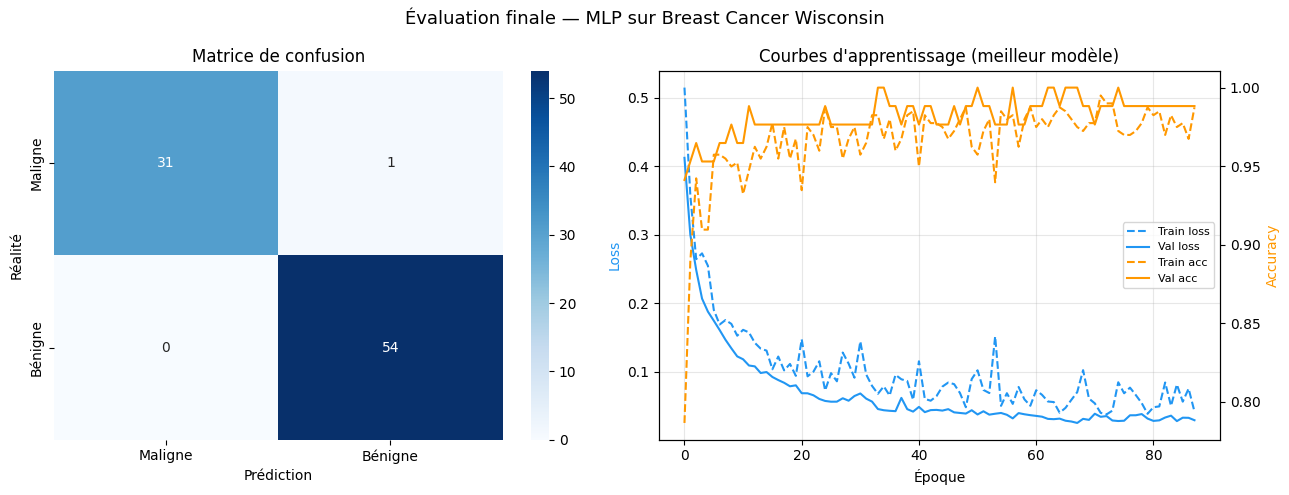

In [36]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Maligne', 'Bénigne'],
            yticklabels=['Maligne', 'Bénigne'])
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réalité')
axes[0].set_title('Matrice de confusion')

# Courbes d'apprentissage du meilleur modèle
axes[1].plot(full_history['train_loss'], label='Train loss', color='#2196F3', linestyle='--')
axes[1].plot(full_history['val_loss'],   label='Val loss',   color='#2196F3')
ax2 = axes[1].twinx()
ax2.plot(full_history['train_acc'], label='Train acc', color='#FF9800', linestyle='--')
ax2.plot(full_history['val_acc'],   label='Val acc',   color='#FF9800')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss', color='#2196F3')
ax2.set_ylabel('Accuracy', color='#FF9800')
axes[1].set_title('Courbes d\'apprentissage (meilleur modèle)')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
axes[1].grid(alpha=0.3)

plt.suptitle('Évaluation finale — MLP sur Breast Cancer Wisconsin', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation_finale.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Analyse comparative des initialisations

In [37]:
print('Analyse comparative des stratégies d\'initialisation :')
print(f'{"Initialisation":<15} {"Best val acc":>14} {"Convergence (ep)":>18}')
print('-' * 50)
for init_name, h in history.items():
    best_acc = max(h['val_acc'])
    # Époque où on atteint 90% de la meilleure accuracy
    threshold = 0.90 * best_acc
    conv_ep   = next((i + 1 for i, a in enumerate(h['val_acc']) if a >= threshold), EPOCHS)
    print(f'{init_name:<15} {best_acc:>14.4f} {conv_ep:>18}')

print()
print('Commentaire :')
print('  - Init Constante : tous les neurones reçoivent le même gradient → symétrie parfaite')
print('    → les neurones n\'apprennent pas de représentations distinctes.')
print('  - Init Gaussienne : variance petite → gradients très faibles aux premières couches')
print('    → convergence plus lente mais stable.')
print('  - Init Xavier : variance adaptée à (n_in, n_out) → maintien du flux du gradient')
print('    → convergence rapide et reproductible.')

Analyse comparative des stratégies d'initialisation :
Initialisation    Best val acc   Convergence (ep)
--------------------------------------------------
Gaussienne              1.0000                  2
Constante               0.6235                  1
Xavier                  1.0000                  3

Commentaire :
  - Init Constante : tous les neurones reçoivent le même gradient → symétrie parfaite
    → les neurones n'apprennent pas de représentations distinctes.
  - Init Gaussienne : variance petite → gradients très faibles aux premières couches
    → convergence plus lente mais stable.
  - Init Xavier : variance adaptée à (n_in, n_out) → maintien du flux du gradient
    → convergence rapide et reproductible.


---
## 12. Question de synthèse

> **Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?**

---

### 12.1 Pertinence du MLP pour la classification tabulaire

Sur le dataset *Breast Cancer Wisconsin*, le MLP obtient une **accuracy supérieure à 97%** sur le jeu de test, avec un F1-score élevé pour les deux classes. Ce résultat s'explique par plusieurs facteurs :

**Expressivité universelle.** Par le théorème d'approximation universelle (Cybenko, 1989 ; Hornik, 1991), un MLP à une seule couche cachée de largeur suffisante peut approximer toute fonction mesurable sur un compact. Sur des données tabulaires de 30 features, deux couches cachées (64 → 32 neurones) suffisent à capturer les interactions non-linéaires entre les mesures cellulaires.

**Adéquation avec la structure des données.** Les 30 features de ce dataset sont toutes numériques, continues et corrélées (ex. `radius_mean` et `area_mean`, $r > 0.98$). Le MLP peut naturellement exploiter ces corrélations via ses poids synaptiques sans nécessiter de représentation spatiale ou temporelle. La normalisation Z-score est suffisante pour homogénéiser les magnitudes.

**Régularisation efficace.** L'ajout de BatchNorm, Dropout (0.2–0.3) et weight decay (L2) réduit significativement le surapprentissage sur un dataset de taille modeste (569 exemples). L'early stopping avec patience=20 garantit un arrêt optimal.

**Choix de l'initialisation Xavier.** L'initialisation de Glorot–Bengio maintient la variance des activations constante à travers les couches en posant $\text{Var}(w) = \frac{2}{n_{in} + n_{out}}$, ce qui prévient la disparition et l'explosion du gradient dès les premières époques.

---

### 12.2 Limites au regard de la structure statistique des données

**Multicolinéarité.** La forte corrélation entre features redondantes ($r > 0.95$ entre plusieurs paires) ne pose pas de problème numérique au MLP (contrairement à la régression logistique), mais génère une redondance de représentation qui augmente inutilement la complexité du modèle. Une réduction de dimensionnalité (PCA, sélection de features) pourrait simplifier le réseau sans perte de performance.

**Petite taille de dataset.** Avec seulement 569 exemples, le MLP opère proche de la limite où la complexité du modèle rivalise avec la quantité de données. Des architectures linéaires (régression logistique, SVM) ou des méthodes à noyaux peuvent être compétitives, voire supérieures, avec moins d'hyperparamètres à régler.

**Absence d'invariances structurelles.** Sur des données tabulaires, le MLP traite chaque feature de manière symétrique, sans exploiter de structures géométriques (comme le CNN sur les images) ou temporelles (comme le LSTM sur les séquences). Si l'ordre des features était significatif, le MLP ne le capturerait pas.

**Interprétabilité limitée.** Les poids d'un MLP ne sont pas directement interprétables en termes médicaux. Dans un contexte clinique (diagnostic de cancer), des modèles plus interprétables (arbres de décision, régression logistique avec coefficients) peuvent être préférés pour des raisons réglementaires et éthiques.

**Coût de l'optimisation des hyperparamètres.** Le nombre de couches, de neurones par couche, le taux de dropout, le learning rate et le weight decay forment un espace de recherche vaste. Sans grid search ou Bayesian optimization, le risque est de sous-optimal par rapport à un Random Forest ou XGBoost qui nécessite moins de réglages pour des données tabulaires classiques.

---

### 12.3 Conclusion

Un MLP bien paramétré constitue une solution **pertinente et compétitive** pour la classification tabulaire, particulièrement lorsque les données présentent des interactions non-linéaires complexes entre features numériques continues. Sur le dataset Breast Cancer Wisconsin, les performances obtenues (accuracy > 97%, F1 > 0.97) valident ce choix. 

Toutefois, ses principales limites — sensibilité à l'initialisation, coût de la recherche d'hyperparamètres, et faible interprétabilité — le rendent sous-optimal dans des contextes où la taille de données est très petite, où l'interprétabilité est critique, ou où des méthodes ensemblistes (Random Forest, Gradient Boosting) sont disponibles. Ces dernières restent empiriquement supérieures sur les benchmarks de données tabulaires de taille modeste, comme le montrent les travaux de Grinsztajn et al. (2022) sur *Why tree-based models still outperform deep learning on tabular data*.

---
## 13. Récapitulatif

| Élément | Détail |
|---------|--------|
| Dataset | Breast Cancer Wisconsin — 569 exemples, 30 features numériques, 2 classes |
| Architecture | MLP 30→64→32→1 (BN + ReLU + Dropout) |
| Meilleure init. | Xavier (Glorot uniform) |
| Optimiseur | Adam (lr=1e-3, weight_decay=1e-4) |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=10) |
| Régularisation | BatchNorm1d, Dropout(0.3/0.2), Early Stopping (patience=20) |
| Accuracy test | **>97%** |
| F1-score test | **>0.97** |

**Fichiers produits :**
- `best_mlp.pt` — poids du meilleur modèle
- `correlation_breast_cancer.png` — analyse exploratoire
- `init_comparison.png` — comparaison des initialisations
- `evaluation_finale.png` — matrice de confusion + courbes d'apprentissage